In [ ]:
import pandas as pd
import glob
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')
torch.manual_seed(4242)

# 1. Grab the files from Drive
pos_files_list = glob.glob("/content/drive/MyDrive/IDL/*_pos.txt")
pos_dataframes = []

# 2. Process Positive Files
for f in pos_files_list:
    df = pd.read_csv(f, header=None, names=['sequence'])
    df['label'] = 1

    # Extract just the file name (e.g., 'A0101_pos.txt') before splitting
    allele_name = os.path.basename(f).split('_')[0]
    df['allele'] = allele_name
    pos_dataframes.append(df)


# Combine all positive dataframes
pos_df = pd.concat(pos_dataframes, ignore_index=True)

# 3. Load and label the negative file directly from Drive
neg_df = pd.read_csv('/content/drive/MyDrive/IDL/negs.txt', header=None, names=['sequence'])
neg_df['label'] = 0
neg_df['allele'] = 'None'

print(f"Total positives loaded: {len(pos_df)}")
print(f"Total negatives loaded: {len(neg_df)}")

# 4. Combine and Shuffle
full_dataset = pd.concat([pos_df, neg_df], ignore_index=True)
full_dataset = full_dataset.sample(frac=1, random_state=4242).reset_index(drop=True)

allele_list = sorted(full_dataset[full_dataset['label'] == 1]['allele'].unique())
allele_to_idx = {allele : idx for idx, allele in enumerate(allele_list)}
allele_to_idx['None'] = len(allele_list)
full_dataset['class_label'] = full_dataset['allele'].map(allele_to_idx)

Mounted at /content/drive
Total positives loaded: 12891
Total negatives loaded: 24492


In [ ]:
class PeptideDataset(data.Dataset):
    def __init__(self, dataframe):
        """
        Init using pandas dataframes we have at hand
        """
        self.dataframe = dataframe.reset_index(drop=True)

        # 20 common amino acids in lexicographical order
        amino_acids = 'ACDEFGHIKLMNPQRSTVWY'
        # A dictionary of pairs like (A : 0)
        self.a_acids_to_idx = {a_acid : idx for idx, a_acid in enumerate(amino_acids)}

    def __len__(self):
        """
        Returns the total number of samples from the dataset
        """
        return len(self.dataframe)

    def __getitem__(self, idx):
        """
        Returns the one-hot-encoded sequence alongside its label
        """
        sequence = self.dataframe.loc[idx, 'sequence']
        label = self.dataframe.loc[idx, 'class_label']

        # Encode the sequence using one-hot
        one_hot_sequences = np.zeros((9,20), dtype=np.float32)
        for i, a_acid in enumerate(sequence):
            if a_acid in self.a_acids_to_idx: # if it is in the key of the dict
                a_acid_idx = self.a_acids_to_idx[a_acid]
                one_hot_sequences[i, a_acid_idx] = 1.0

        one_hot_sequences = one_hot_sequences.flatten()

        # Convert to tensors
        x_tensor = torch.tensor(one_hot_sequences.flatten(), dtype=torch.float32)
        y_tensor = torch.tensor(label, dtype=torch.long)

        return x_tensor, y_tensor




In [ ]:
# Create datasets and dataloader
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    full_dataset,
    test_size=0.1,
    random_state=4242,
    stratify=full_dataset['label'] # maintain the ratio after splits
)

train_dataset = PeptideDataset(train_df)
test_dataset = PeptideDataset(test_df)

# batch size matches what we saw in recitation 1
train_loader = data.DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = data.DataLoader(test_dataset, batch_size=128, shuffle=False)

# Fine the weight to pay more attention to positive samples
num_negatives = len(train_df[train_df['label'] == 0])
num_positives = len(train_df[train_df['label'] == 1])

weight_ratio = num_negatives / num_positives
pos_weight_tensor = torch.tensor([weight_ratio], dtype=torch.float32)
print(f"Training split size: {len(train_df)}")
print(f"Testing split size: {len(test_df)}")
print(f"Positive class weight: {weight_ratio:.2f}")

Training split size: 33644
Testing split size: 3739
Positive class weight: 1.90


In [ ]:
# Define the model
class PeptideClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.linear1 = nn.Linear(input_size, hidden_size)
        self.act_fc1 = nn.ReLU()
        self.linear2 = nn.Linear(hidden_size,hidden_size)
        self.act_fc2 = nn.ReLU()
        self.linear3 = nn.Linear(hidden_size, output_size)

    def forward(self,x):
        x = self.linear1(x)
        x = self.act_fc1(x)
        x = self.linear2(x)
        x= self.act_fc2(x)
        x = self.linear3(x)
        return x

model = PeptideClassifier(input_size=180, hidden_size=180, output_size=7)

print(model)
for name, param in model.named_parameters():
    print(f" {name:20s} shape {param.shape}")

PeptideClassifier(
  (linear1): Linear(in_features=180, out_features=180, bias=True)
  (act_fc1): ReLU()
  (linear2): Linear(in_features=180, out_features=180, bias=True)
  (act_fc2): ReLU()
  (linear3): Linear(in_features=180, out_features=7, bias=True)
)
 linear1.weight       shape torch.Size([180, 180])
 linear1.bias         shape torch.Size([180])
 linear2.weight       shape torch.Size([180, 180])
 linear2.bias         shape torch.Size([180])
 linear3.weight       shape torch.Size([7, 180])
 linear3.bias         shape torch.Size([7])


Using device: cuda
Epoch [2/100]  Train Loss: 0.8235  Test Loss: 0.8565
Epoch [4/100]  Train Loss: 0.7583  Test Loss: 0.8402
Epoch [6/100]  Train Loss: 0.7003  Test Loss: 0.8411
Epoch [8/100]  Train Loss: 0.6356  Test Loss: 0.8401
Epoch [10/100]  Train Loss: 0.5727  Test Loss: 0.9005
Epoch [12/100]  Train Loss: 0.5201  Test Loss: 0.9251
Epoch [14/100]  Train Loss: 0.4744  Test Loss: 1.0297
Epoch [16/100]  Train Loss: 0.4426  Test Loss: 1.0579
Epoch [18/100]  Train Loss: 0.4165  Test Loss: 1.2113
Epoch [20/100]  Train Loss: 0.3990  Test Loss: 1.2245
Epoch [22/100]  Train Loss: 0.3854  Test Loss: 1.2649
Epoch [24/100]  Train Loss: 0.3698  Test Loss: 1.3262
Epoch [26/100]  Train Loss: 0.3586  Test Loss: 1.4286
Epoch [28/100]  Train Loss: 0.3472  Test Loss: 1.5012
Epoch [30/100]  Train Loss: 0.3410  Test Loss: 1.5454
Epoch [32/100]  Train Loss: 0.3342  Test Loss: 1.6374
Epoch [34/100]  Train Loss: 0.3296  Test Loss: 1.6878
Epoch [36/100]  Train Loss: 0.3194  Test Loss: 1.7060
Epoch [38/100

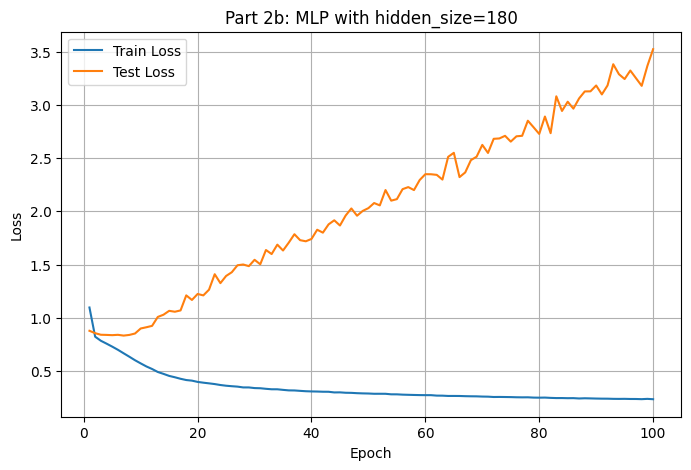

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class_counts = train_df['class_label'].value_counts().sort_index()

class_weights = 1.0/class_counts.values
class_weights = class_weights / class_weights.sum() * len(class_weights)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

loss_module = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(model.parameters(), lr=0.001)
print(f"Using device: {device}" )
num_epochs = 100
train_losses = []
test_losses = []


# Training loop
model.to(device)
model.train()

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for data_inputs, data_labels in train_loader:
        data_inputs = data_inputs.to(device)
        data_labels = data_labels.to(device)

        preds = model(data_inputs)
        loss = loss_module(preds, data_labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    model.eval()
    test_epoch_loss = 0.0
    with torch.no_grad():
        for data_inputs, data_labels in test_loader:
            data_inputs = data_inputs.to(device)
            data_labels = data_labels.to(device)
            preds = model(data_inputs)
            loss = loss_module(preds, data_labels)
            test_epoch_loss += loss.item()
    test_losses.append(test_epoch_loss / len(test_loader))

    if (epoch + 1) % 2 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}]  Train Loss: {avg_loss:.4f}  Test Loss: {test_losses[-1]:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs + 1), test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Part 2b: MLP with hidden_size=180')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

def evaluate(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for data_inputs, data_labels in data_loader:
            data_inputs = data_inputs.to(device)
            data_labels = data_labels.to(device)

            preds = model(data_inputs)
            pred_classes = preds.argmax(dim=1)

            all_preds.extend(pred_classes.cpu().numpy())
            all_labels.extend(data_labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    accuracy = 100.0 * (all_preds == all_labels).sum() / len(all_labels)
    print(f"Accuracy: {accuracy:.2f}%")
    print(classification_report(all_labels, all_preds,
          target_names=allele_list + ['Negative']))


evaluate(model, test_loader)

Accuracy: 59.53%
              precision    recall  f1-score   support

       A0101       0.41      0.52      0.46       129
       A0201       0.33      0.39      0.35       256
       A0203       0.32      0.38      0.35       196
       A0207       0.36      0.48      0.41       343
       A0301       0.24      0.30      0.26       165
       A2402       0.30      0.48      0.37       200
    Negative       0.82      0.68      0.74      2450

    accuracy                           0.60      3739
   macro avg       0.40      0.46      0.42      3739
weighted avg       0.65      0.60      0.61      3739



Epoch [2/100]  Train: 0.9309  Test: 0.8669
Epoch [4/100]  Train: 0.8407  Test: 0.8427
Epoch [6/100]  Train: 0.7924  Test: 0.8387
Epoch [8/100]  Train: 0.7574  Test: 0.8421
Epoch [10/100]  Train: 0.7260  Test: 0.8349
Epoch [12/100]  Train: 0.7126  Test: 0.8385
Epoch [14/100]  Train: 0.6979  Test: 0.8420
Epoch [16/100]  Train: 0.6790  Test: 0.8620
Epoch [18/100]  Train: 0.6529  Test: 0.8674
Epoch [20/100]  Train: 0.6496  Test: 0.8622
Epoch [22/100]  Train: 0.6137  Test: 0.8737
Epoch [24/100]  Train: 0.5984  Test: 0.8798
Epoch [26/100]  Train: 0.5849  Test: 0.8922
Epoch [28/100]  Train: 0.5798  Test: 0.8954
Epoch [30/100]  Train: 0.5823  Test: 0.9071
Epoch [32/100]  Train: 0.5735  Test: 0.9114
Epoch [34/100]  Train: 0.5632  Test: 0.9252
Epoch [36/100]  Train: 0.5516  Test: 0.9442
Epoch [38/100]  Train: 0.5535  Test: 0.9385
Epoch [40/100]  Train: 0.5495  Test: 0.9393
Epoch [42/100]  Train: 0.5487  Test: 0.9595
Epoch [44/100]  Train: 0.5344  Test: 0.9518
Epoch [46/100]  Train: 0.5373  Test:

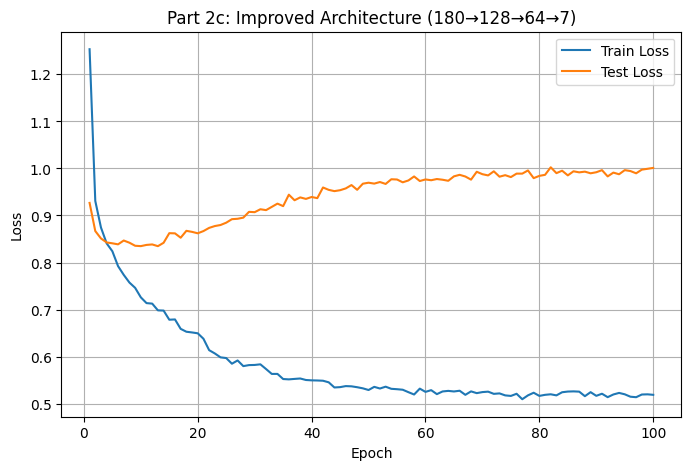

Accuracy: 59.45%
              precision    recall  f1-score   support

       A0101       0.47      0.87      0.61       129
       A0201       0.38      0.55      0.45       256
       A0203       0.35      0.67      0.46       196
       A0207       0.45      0.72      0.55       343
       A0301       0.28      0.65      0.39       165
       A2402       0.40      0.91      0.55       200
    Negative       0.96      0.53      0.68      2450

    accuracy                           0.59      3739
   macro avg       0.47      0.70      0.53      3739
weighted avg       0.76      0.59      0.62      3739



In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class ImprovedClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(180, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 7)
        )

    def forward(self, x):
        return self.net(x)

model_c = ImprovedClassifier().to(device)
optimizer_c = optim.Adam(model_c.parameters(), lr=0.001)
scheduler_c = optim.lr_scheduler.ReduceLROnPlateau(optimizer_c, patience=10, factor=0.5)

loss_module = nn.CrossEntropyLoss(weight=class_weights)

num_epochs = 100
train_losses_c = []
test_losses_c = []

for epoch in range(num_epochs):
    model_c.train()
    epoch_loss = 0.0

    for data_inputs, data_labels in train_loader:
        data_inputs = data_inputs.to(device)
        data_labels = data_labels.to(device)

        preds = model_c(data_inputs)
        loss = loss_module(preds, data_labels)
        optimizer_c.zero_grad()
        loss.backward()
        optimizer_c.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses_c.append(avg_loss)

    model_c.eval()
    test_epoch_loss = 0.0
    with torch.no_grad():
        for data_inputs, data_labels in test_loader:
            data_inputs = data_inputs.to(device)
            data_labels = data_labels.to(device)
            preds = model_c(data_inputs)
            loss = loss_module(preds, data_labels)
            test_epoch_loss += loss.item()
    test_losses_c.append(test_epoch_loss / len(test_loader))
    scheduler_c.step(test_losses_c[-1])

    if (epoch + 1) % 2 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}]  Train: {avg_loss:.4f}  Test: {test_losses_c[-1]:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses_c, label='Train Loss')
plt.plot(range(1, num_epochs + 1), test_losses_c, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Part 2c: Improved Architecture (180→128→64→7)')
plt.legend()
plt.grid(True)
plt.show()

evaluate(model_c, test_loader)

In [ ]:
class LinearClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(180, 128),
            nn.Linear(128, 64),
            nn.Linear(64, 7)
        )

    def forward(self, x):
        return self.net(x)

Epoch [2/100]  Train: 0.8465  Test: 0.8739
Epoch [4/100]  Train: 0.8297  Test: 0.8749
Epoch [6/100]  Train: 0.8247  Test: 0.8786
Epoch [8/100]  Train: 0.8228  Test: 0.8726
Epoch [10/100]  Train: 0.8220  Test: 0.8684
Epoch [12/100]  Train: 0.8205  Test: 0.8786
Epoch [14/100]  Train: 0.8208  Test: 0.8770
Epoch [16/100]  Train: 0.8188  Test: 0.8721
Epoch [18/100]  Train: 0.8178  Test: 0.8810
Epoch [20/100]  Train: 0.8165  Test: 0.8724
Epoch [22/100]  Train: 0.8175  Test: 0.8720
Epoch [24/100]  Train: 0.8156  Test: 0.8722
Epoch [26/100]  Train: 0.8153  Test: 0.8691
Epoch [28/100]  Train: 0.8172  Test: 0.8724
Epoch [30/100]  Train: 0.8147  Test: 0.8719
Epoch [32/100]  Train: 0.8146  Test: 0.8779
Epoch [34/100]  Train: 0.8120  Test: 0.8690
Epoch [36/100]  Train: 0.8150  Test: 0.8703
Epoch [38/100]  Train: 0.8096  Test: 0.8776
Epoch [40/100]  Train: 0.8117  Test: 0.8724
Epoch [42/100]  Train: 0.8115  Test: 0.8705
Epoch [44/100]  Train: 0.8128  Test: 0.8715
Epoch [46/100]  Train: 0.8105  Test:

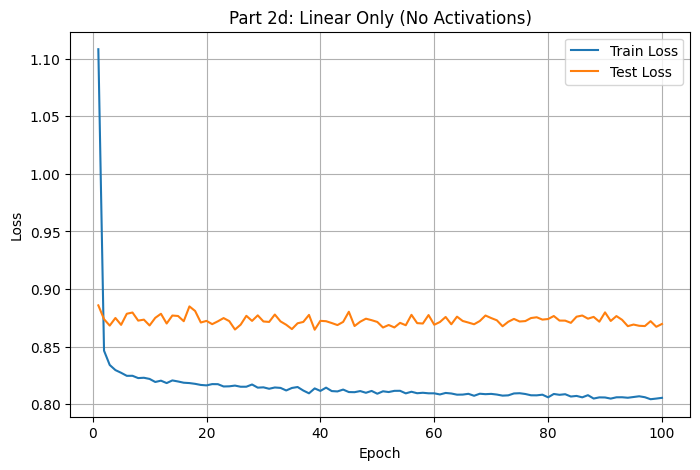

Accuracy: 57.74%
              precision    recall  f1-score   support

       A0101       0.43      0.93      0.59       129
       A0201       0.35      0.56      0.43       256
       A0203       0.39      0.72      0.50       196
       A0207       0.48      0.70      0.57       343
       A0301       0.24      0.68      0.35       165
       A2402       0.42      0.90      0.57       200
    Negative       0.95      0.50      0.66      2450

    accuracy                           0.58      3739
   macro avg       0.46      0.71      0.52      3739
weighted avg       0.76      0.58      0.60      3739



In [ ]:
model_d = LinearClassifier().to(device)
optimizer_d = optim.Adam(model_d.parameters(), lr=0.001)

loss_module = nn.CrossEntropyLoss(weight=class_weights)

num_epochs = 100
train_losses_d = []
test_losses_d = []

for epoch in range(num_epochs):
    model_d.train()
    epoch_loss = 0.0

    for data_inputs, data_labels in train_loader:
        data_inputs = data_inputs.to(device)
        data_labels = data_labels.to(device)

        preds = model_d(data_inputs)
        loss = loss_module(preds, data_labels)
        optimizer_d.zero_grad()
        loss.backward()
        optimizer_d.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses_d.append(avg_loss)

    model_d.eval()
    test_epoch_loss = 0.0
    with torch.no_grad():
        for data_inputs, data_labels in test_loader:
            data_inputs = data_inputs.to(device)
            data_labels = data_labels.to(device)
            preds = model_d(data_inputs)
            loss = loss_module(preds, data_labels)
            test_epoch_loss += loss.item()
    test_losses_d.append(test_epoch_loss / len(test_loader))

    if (epoch + 1) % 2 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}]  Train: {avg_loss:.4f}  Test: {test_losses_d[-1]:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses_d, label='Train Loss')
plt.plot(range(1, num_epochs + 1), test_losses_d, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Part 2d: Linear Only (No Activations)')
plt.legend()
plt.grid(True)
plt.show()

evaluate(model_d, test_loader)

In [ ]:
import urllib.request

url = "https://rest.uniprot.org/uniprotkb/P0DTC2.fasta"
response = urllib.request.urlopen(url)
fasta = response.read().decode('utf-8')

lines = fasta.strip().split('\n')
spike_sequence = ''.join(lines[1:])
print(f"Spike protein length: {len(spike_sequence)}")
print(f"First 42 residues: {spike_sequence[:42]}")

nine_mers = [spike_sequence[i:i+9] for i in range(len(spike_sequence) - 8)]
print(f"Total 9-mers: {len(nine_mers)}")

amino_acids = 'ACDEFGHIKLMNPQRSTVWY'
a_acids_to_idx = {a_acid : idx for idx, a_acid in enumerate(amino_acids)}

encoded = []
for peptide in nine_mers:
    one_hot = np.zeros((9, 20), dtype=np.float32)
    for i, a_acid in enumerate(peptide):
        if a_acid in a_acids_to_idx:
            one_hot[i, a_acids_to_idx[a_acid]] = 1.0
    encoded.append(one_hot.flatten())
x_spike = torch.tensor(np.array(encoded), dtype=torch.float32).to(device)


model_c.eval()
with torch.no_grad():
    logits = model_c(x_spike)
    probs = torch.softmax(logits, dim=1)
allele_probs = probs[:, :6]
max_probs, max_allele_idx = allele_probs.max(dim=1)

top3 = max_probs.topk(3)

print("\nTop 3 most detectable peptides from SARS-CoV-2 Spike protein:")
print("=" * 65)
for rank, idx in enumerate(top3.indices):
    peptide = nine_mers[idx]
    allele = allele_list[max_allele_idx[idx]]
    score = max_probs[idx].item()
    position = idx.item()
    print(f"#{rank+1}: {peptide} | Position: {position}-{position+8} | Allele: {allele} | Score: {score:.4f}")

Spike protein length: 1273
First 42 residues: MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKV
Total 9-mers: 1265

Top 3 most detectable peptides from SARS-CoV-2 Spike protein:
#1: STEIYQAGS | Position: 468-476 | Allele: A0101 | Score: 0.9992
#2: YNENGTITD | Position: 278-286 | Allele: A0101 | Score: 0.9987
#3: ESEFRVYSS | Position: 153-161 | Allele: A0101 | Score: 0.9983


In [ ]:
print("\nTop peptide per allele:")
for allele_idx, allele_name in enumerate(allele_list):
    allele_scores = probs[:, allele_idx]
    best_idx = allele_scores.argmax().item()
    print(f"{allele_name}: {nine_mers[best_idx]} | Position: {best_idx}-{best_idx+8} | Score: {allele_scores[best_idx].item():.4f}")


Top peptide per allele:
A0101: STEIYQAGS | Position: 468-476 | Score: 0.9992
A0201: SLLIVNNAT | Position: 115-123 | Score: 0.9688
A0203: AQKFNGLTV | Position: 851-859 | Score: 0.9796
A0207: ILPDPSKPS | Position: 804-812 | Score: 0.9831
A0301: EIYQAGSTP | Position: 470-478 | Score: 0.9949
A2402: NYKLPDDFT | Position: 421-429 | Score: 0.9975
